# I - Préliminaires - Fonctions utiles

In [82]:
%matplotlib inline

In [83]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Matrice de confusion',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    from http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    :param cm: (numpy matrix) confusion matrix
    :param classes: [str]
    :param normalize: (bool)
    :param title: (str)
    :param cmap: (matplotlib color map)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
    plt.figure(figsize=(8, 8))   
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')

# II - Entraînement d'un CNN pour la classification sur CIFAR10

### II.1. Chargement et Dimensionnement de la base CIFAR10

In [84]:
from keras import backend as K
print(K.backend())

tensorflow


In [85]:
from keras.datasets import cifar10

Réduction de la taille du dataset (pour accélérer l'apprentissage), et standardisation des données

In [86]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
print("Dimension de la base d'apprentissage CIFAR10 :",x_train_full.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train_full.shape)
print("Dimension de la base de test CIFAR10 :",x_test_full.shape)

Dimension de la base d'apprentissage CIFAR10 : (50000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (50000, 1)
Dimension de la base de test CIFAR10 : (10000, 32, 32, 3)


/Users/linnan/Documents/CSC_4MI04_TP3/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [87]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [88]:
n_training_samples = 5000
n_other_samples = 2000

def standardize(img_data):
    img_data_mean = np.mean(img_data, axis=(1,2), keepdims=True)
    img_data_std = np.std(img_data, axis=(1,2), keepdims=True)
    img_data = (img_data - img_data_mean) / img_data_std
    return img_data

train_ids = np.random.choice(len(x_train_full), size=n_training_samples, replace=False)
other_ids = np.random.choice(len(x_test_full), size=n_other_samples, replace=False)

n_valid = n_other_samples // 2
val_ids = other_ids[:n_valid]
test_ids = other_ids[n_valid:]

x_train_initial, y_train = x_train_full[train_ids], y_train_full[train_ids]
x_val_initial, y_val = x_test_full[val_ids], y_test_full[val_ids]
x_test_initial, y_test = x_test_full[test_ids], y_test_full[test_ids]

x_train = standardize(x_train_initial)
x_val = standardize(x_val_initial)
x_test = standardize(x_test_initial)

print("Dimension de notre base d'apprentissage :",x_train.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train.shape)
print("Dimension de notre base de validation :",x_val.shape)
print("Dimension de notre base de test :",x_test.shape)


Dimension de notre base d'apprentissage : (5000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (5000, 1)
Dimension de notre base de validation : (1000, 32, 32, 3)
Dimension de notre base de test : (1000, 32, 32, 3)


On affiche quelques images d'entraînement avec leur étiquette...

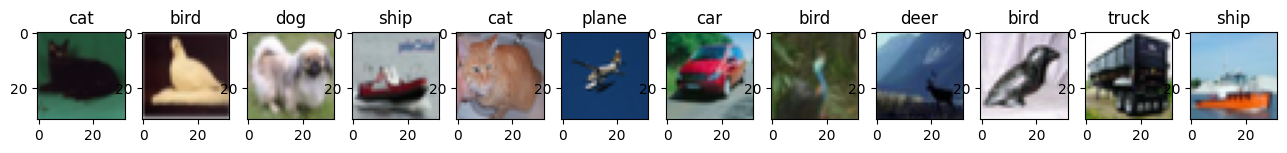

In [89]:
n_display = 12
random_ids = np.random.choice(len(x_train), n_display, replace=False)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_train_initial[random_ids[k]])
    axarr[k].title.set_text(classes[y_train[random_ids[k]][0]])

In [90]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print("Dimension des matrices d'étiquette de classe (train) :",y_train.shape)
print("Dimension des matrices d'étiquette de classe (val) :",y_val.shape)
print("Dimension des matrices d'étiquette de classe (test) :",y_test.shape)

Dimension des matrices d'étiquette de classe (train) : (5000, 10)
Dimension des matrices d'étiquette de classe (val) : (1000, 10)
Dimension des matrices d'étiquette de classe (test) : (1000, 10)


### II.2. Definition de l'architecture du CNN

Un simple réseau convolutionnel... 

In [91]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Activation
from keras.regularizers import l2
from keras import Input

model = Sequential()
model.add(Input(shape = (32,32,3)))
model.add(Conv2D(filters=8, 
                kernel_size = (3, 3),
                activation = 'relu',
                padding = 'same',
                kernel_regularizer = l2(0.00)))
model.add(Dropout(0.0))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu', kernel_regularizer = l2(0.00)))
model.add(Dropout(0.0))
model.add(Dense(10, activation='softmax', kernel_regularizer = l2(0.00)))
model.add(Dropout(0.0))

On enregistre les poids initiaux pour plus tard...

In [92]:
weights_init = model.get_weights()

### II.3. Definition de la fonction de coût et choix de l'algorithme d'optimisation

In [93]:
from keras.optimizers import Adam, SGD

opt = SGD(learning_rate=0.01,momentum=0.0)
# opt = Adam(lr=0.001)
model.compile(optimizer=opt,
             loss='categorical_crossentropy',
             metrics=['acc'])

On affiche un résumé de la structure du modèle...

In [94]:
print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,010 (515.66 KB)

 Trainable params: 132,010 (515.66 KB)

 Non-trainable params: 0 (0.00 B)

None


### II.4. Entraînement du CNN

*Definition du callback. A passer en première lecture.*

In [95]:
from keras.callbacks import Callback
from keras.callbacks import ModelCheckpoint
import time

class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, batch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)
time_callback = TimeHistory()
filepath = "my_model.h5"
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max', save_freq=2)

callbacks = [time_callback, checkpoint]

In [96]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1, validation_data=(x_val, y_val),
                    callbacks=callbacks)

Epoch 1/20
  1/157 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - acc: 0.0938 - loss: 2.7434

/Users/linnan/Documents/CSC_4MI04_TP3/.venv/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to my_model.h5



Epoch 1: finished saving model to my_model.h5



Epoch 1: finished saving model to my_model.h5


...


Epoch 20: finished saving model to my_model.h5



Epoch 20: finished saving model to my_model.h5



Epoch 20: finished saving model to my_model.h5



Epoch 20: finished saving model to my_model.h5



Epoch 20: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8648 - loss: 0.4503 - val_acc: 0.4200 - val_loss: 2.3654


Statistiques sur le temps d'entraînement d'une epoch

In [97]:
times = time_callback.times
print("Mean: {}".format(np.mean(times)))
print("Std: {}".format(np.std(times)))

Mean: 0.6570994853973389
Std: 0.11834750309939654


Tracé des courbes d'évolution des fonctions de coût

In [98]:
history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

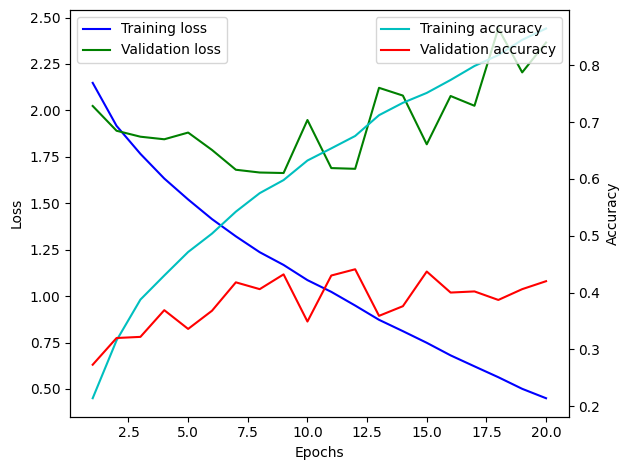

In [99]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

epochs = range(1, len(history_dict['acc']) + 1)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.plot(epochs, loss_values, color='b', label='Training loss')
ax1.plot(epochs, val_loss_values, color='g', label='Validation loss')
ax1.tick_params(axis='y')
plt.legend()

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

ax2.set_ylabel('Accuracy')  # we already handled the x-label with ax1
ax2.plot(epochs, acc_values, color='c', label='Training accuracy')
ax2.plot(epochs, val_acc_values, color='r', label='Validation accuracy')
ax2.tick_params(axis='y')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.legend(loc=1)
plt.show()

### II.5. Entraînement d'un CNN avec points d'arrêt et reprises (à passer en première lecture)

Pour des entraînements plus conséquents, il est primordial d'enregistrer les modèles intermédiaires afin de ne pas tout perdre si l'apprentissage venait à s'interrompre de façon impromptue. On peut enregistrer le modèle dans un fichier .hdf

Si vous regardez plus attentivement, lors de l'entrainement précédent nous avons crée un object **ModelCheckpoint**. Il permet d'enregistrer le meilleur modèle (au sens d'une metrique à préciser) dans un fichier nommé *my_model.h5*. Verifiez que ce fichier se trouve bien votre espace de travail.

L'argument ***period*** de l'objet ModelCheckpoint vous permet de definir la fréquence des enregistrements.

In [100]:
from keras.models import load_model

Une fois le modele obtenu, on peut l'enregister et le recharger comme ceci: load_model(filepath)

In [101]:
from keras.models import load_model
from keras.optimizers import SGD

import pathlib
file = pathlib.Path(filepath)
if file.exists():
    model = load_model(filepath, compile=False)
else:
    model.set_weights(weights_init)

model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.0),
             loss='categorical_crossentropy',
             metrics=['accuracy'])

callbacks = [time_callback, checkpoint]
history_2 = model.fit(x_train, y_train, batch_size=8, epochs=10, verbose=1, validation_data=(x_val, y_val),
                      callbacks = callbacks)

Epoch 1/10
  1/625 ━━━━━━━━━━━━━━━━━━━━ 1:27 140ms/step - accuracy: 0.5000 - loss: 0.7721


Epoch 1: finished saving model to my_model.h5



Epoch 1: finished saving model to my_model.h5



Epoch 1: finished saving model to my_model.h5



Epoch 1: finished saving model to my_model.h5


...


Epoch 10: finished saving model to my_model.h5



Epoch 10: finished saving model to my_model.h5



Epoch 10: finished saving model to my_model.h5



Epoch 10: finished saving model to my_model.h5



Epoch 10: finished saving model to my_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 0.4430 - val_loss: 3.3867


# III - Test et Évaluation du modèle en prédiction

### III.1. Test du modèle sur les données de test

Testons la prédiction de notre modèle sur quelques images de test au hasard...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


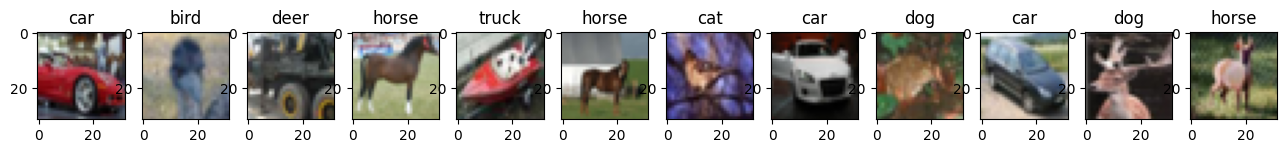

In [102]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
pred = np.argmax(model.predict(x_test[random_ids]), axis=1)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_test_initial[random_ids[k]])
    axarr[k].title.set_text(classes[pred[k]])

Vos premiers résultats semblent-ils corrects ?

Hum ! Affichons à présent la précision sur l'ensemble de votre base :

In [103]:
print("Précision du réseau sur les {} images d'entraînement : {:.2f} %".format(n_training_samples, 100 * history_dict['acc'][-1]))
print("Précision du réseau sur les {} images de validation : {:.2f} %".format(n_valid, 100 * history_dict['val_acc'][-1]))

Précision du réseau sur les 5000 images d'entraînement : 86.48 %
Précision du réseau sur les 1000 images de validation : 42.00 %


In [104]:
def accuracy_per_class(model):
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=np.int64)
    
    pred = np.argmax(model.predict(x_test), axis=1)
    for i in range(len(y_test)):
        confusion_matrix[np.argmax(y_test[i]), pred[i]] += 1
    
    print("{:<10} {:^10}".format("Classe", "Précision (%)"))
    total_correct = 0
    for i in range(n_classes):
        class_total = confusion_matrix[i, :].sum()
        class_correct = confusion_matrix[i, i]
        total_correct += class_correct
        percentage_correct = 100.0 * float(class_correct) / class_total
        print('{:<10} {:^10.2f}'.format(classes[i], percentage_correct))
    test_acc = 100.0 * float(total_correct) / len(y_test)
    print("Précision du réseau sur les {} images de test : {:.2f} %".format(len(y_test),test_acc))
    return confusion_matrix

confusion_matrix = accuracy_per_class(model)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step
Classe     Précision (%)
plane        51.49   
car          60.76   
bird         32.74   
cat          25.71   
deer         36.00   
dog          46.09   
frog         45.36   
horse        52.83   
ship         60.61   
truck        51.76   
Précision du réseau sur les 1000 images de test : 45.70 %


### III.2. Matrices de Confusion

Les matrices de confusion nous renseignent plus précisément sur la nature des erreurs commises par notre modèle.

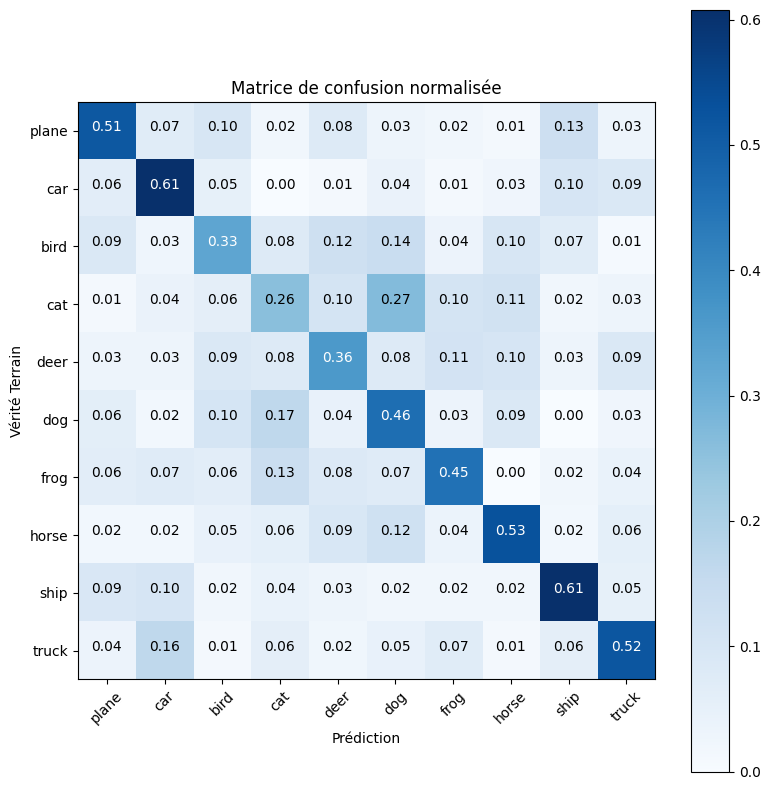

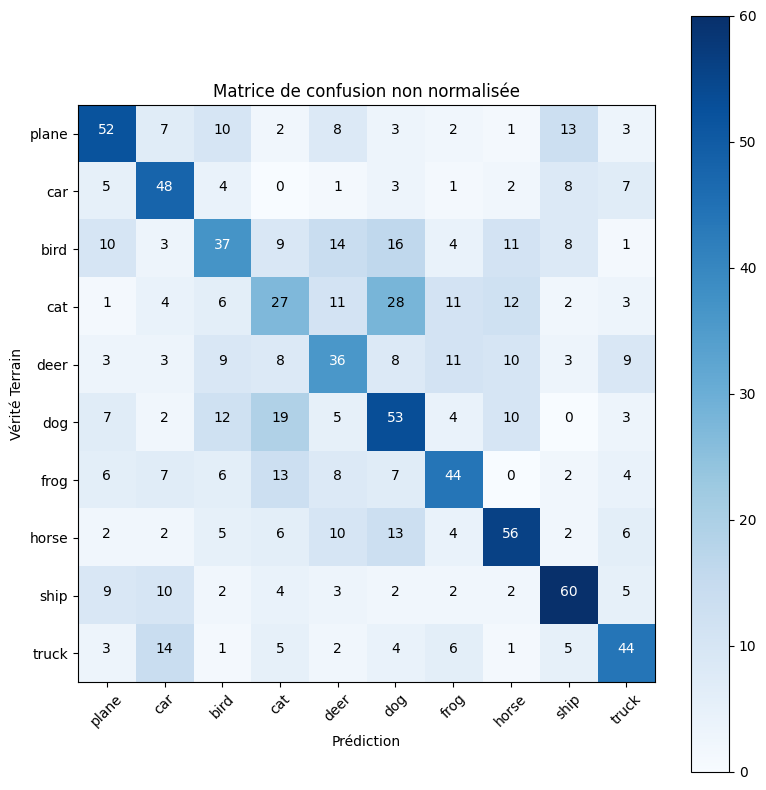

In [105]:
# Plot normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes, normalize=True,
                      title='Matrice de confusion normalisée')

# Plot non-normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes,
                      title='Matrice de confusion non normalisée')

# IV - Visualisation des zones d'activation

In [106]:
from keras.models import Model

reduced_model = Model(inputs=model.inputs, outputs=model.layers[1].output)
reduced_model.summary()

Model: "functional_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 32, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

In [107]:
feature_maps = reduced_model.predict(x_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step


In [108]:
def get_mask(k):
    feature_maps_positive = np.maximum(feature_maps[k], 0)
    mask = np.sum(feature_maps_positive,axis=2)
    mask = mask / np.max(mask)
    return mask

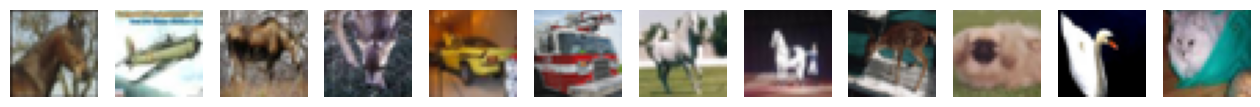

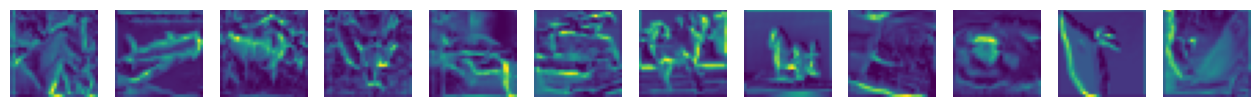

In [109]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
f, rd_img = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    img = x_test_initial[random_ids[k]]
    rd_img[k].imshow(img)
    rd_img[k].axis('off')
f, rd_maps = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    mask = get_mask(random_ids[k])
    rd_maps[k].imshow(mask)
    rd_maps[k].axis('off')

# V - Approfondissement du modele

Dans cette partie, on propose un CNN plus profond que l'architecture de base afin d'ameliorer les performances. L'objectif est de comparer ce modele au reseau initial, d'afficher ses hyperparametres, ses courbes d'apprentissage et ses matrices de confusion, puis d'en discuter les avantages et les limites.

### V.1. Definition d'un CNN plus profond

Le modele ci-dessous ajoute plusieurs couches de convolution successives. Les tailles des tenseurs restent compatibles grace au `padding='same'` et aux couches de `MaxPooling2D` qui reduisent progressivement la resolution spatiale.

In [110]:
from keras.layers import BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import plot_model

improved_model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.30),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.50),
    Dense(10, activation='softmax')
])

improved_optimizer = Adam(learning_rate=1e-3)

improved_model.compile(
    optimizer=improved_optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(improved_model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,882 (1.54 MB)

 Trainable params: 403,434 (1.54 MB)

 Non-trainable params: 448 (1.75 KB)

None


### V.2. Representation graphique et hyperparametres

Le bloc suivant tente d'afficher un schema du reseau. Si `Graphviz` n'est pas disponible, le notebook affiche simplement un message et conserve le resume textuel du modele.

In [111]:
improved_hyperparams = {
    'architecture': 'CNN multi-couches',
    'input_shape': (32, 32, 3),
    'conv_blocks': [(32, 32), (64, 64), (128,)],
    'kernel_size': (3, 3),
    'padding': 'same',
    'pool_size': (2, 2),
    'dense_units': 128,
    'dropout_rates': [0.25, 0.25, 0.30, 0.50],
    'regularization_dense': 'l2(1e-4)',
    'optimizer': 'Adam',
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs_max': 20,
    'early_stopping_patience': 5,
    'reduce_lr_patience': 3,
}

for key, value in improved_hyperparams.items():
    print(f"{key}: {value}")

try:
    plot_model(improved_model, show_shapes=True, show_layer_names=True, dpi=80)
except Exception as e:
    print('Schema graphique non genere (Graphviz/pydot indisponible).')
    print(e)

architecture: CNN multi-couches
input_shape: (32, 32, 3)
conv_blocks: [(32, 32), (64, 64), (128,)]
kernel_size: (3, 3)
padding: same
pool_size: (2, 2)
dense_units: 128
dropout_rates: [0.25, 0.25, 0.3, 0.5]
regularization_dense: l2(1e-4)
optimizer: Adam
learning_rate: 0.001
batch_size: 32
epochs_max: 20
early_stopping_patience: 5
reduce_lr_patience: 3
You must install pydot (`pip install pydot`) for `plot_model` to work.


### V.3. Entrainement du modele approfondi

On utilise `EarlyStopping` pour eviter un surapprentissage trop important et `ReduceLROnPlateau` pour diminuer automatiquement le taux d'apprentissage si la validation stagne.

In [112]:
improved_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

improved_history = improved_model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=20,
    verbose=1,
    validation_data=(x_val, y_val),
    callbacks=improved_callbacks
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.1520 - loss: 2.4258 - val_accuracy: 0.1180 - val_loss: 4.6465 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1958 - loss: 2.1696 - val_accuracy: 0.2070 - val_loss: 2.3897 - learning_rate: 0.0010
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.2436 - loss: 2.0396 - val_accuracy: 0.3070 - val_loss: 2.0278 - learning_rate: 0.0010
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.2904 - loss: 1.9366 - val_accuracy: 0.3190 - val_loss: 2.0735 - learning_rate: 0.0010
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.3082 - loss: 1.8872 - val_accuracy: 0.3830 - val_loss: 1.7199 - learning_rate: 0.0010
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3312 - loss: 1.8399 - val_accuracy: 0.3750 - val_loss: 1.7873 - learning_rate: 0.0010
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3580 - loss: 1.

### V.4. Comparaison avec le modele de base

On compare les courbes du modele initial (`history`) et du modele approfondi (`improved_history`).

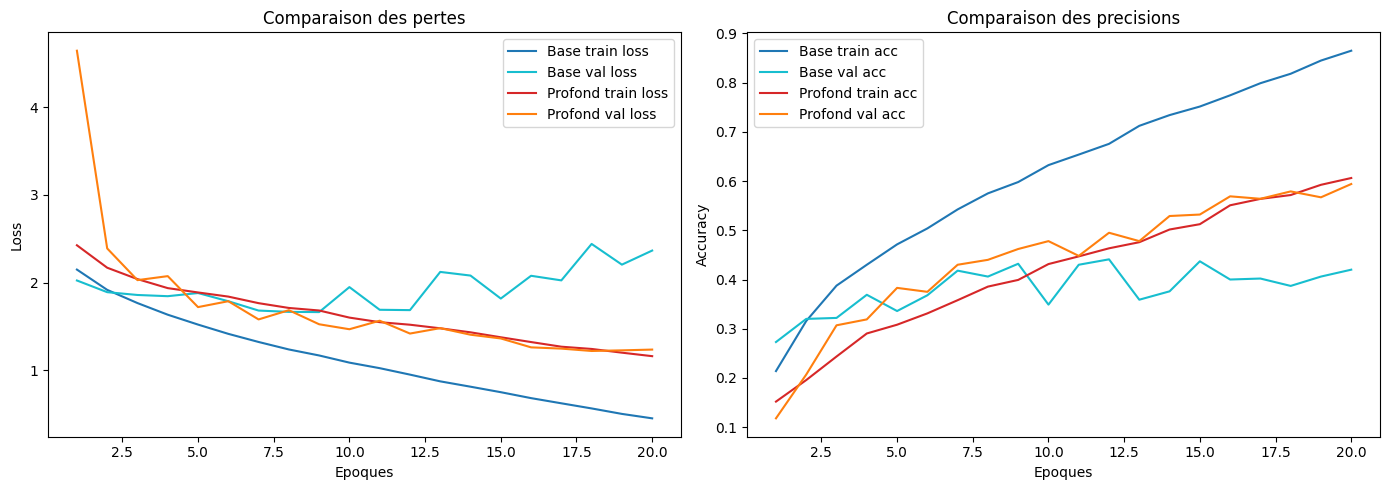

Modele de base - derniere val_accuracy : 0.41999998688697815
Modele approfondi - meilleure val_accuracy : 0.593999981880188


In [113]:
def get_history_key(history_obj, candidates):
    for key in candidates:
        if key in history_obj.history:
            return key
    raise KeyError(f"Aucune des cles {candidates} n'a ete trouvee dans l'historique.")

baseline_acc_key = get_history_key(history, ['accuracy', 'acc'])
baseline_val_acc_key = get_history_key(history, ['val_accuracy', 'val_acc'])
improved_acc_key = get_history_key(improved_history, ['accuracy', 'acc'])
improved_val_acc_key = get_history_key(improved_history, ['val_accuracy', 'val_acc'])

baseline_epochs = range(1, len(history.history['loss']) + 1)
improved_epochs = range(1, len(improved_history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_epochs, history.history['loss'], label='Base train loss', color='tab:blue')
axes[0].plot(baseline_epochs, history.history['val_loss'], label='Base val loss', color='tab:cyan')
axes[0].plot(improved_epochs, improved_history.history['loss'], label='Profond train loss', color='tab:red')
axes[0].plot(improved_epochs, improved_history.history['val_loss'], label='Profond val loss', color='tab:orange')
axes[0].set_title('Comparaison des pertes')
axes[0].set_xlabel('Epoques')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(baseline_epochs, history.history[baseline_acc_key], label='Base train acc', color='tab:blue')
axes[1].plot(baseline_epochs, history.history[baseline_val_acc_key], label='Base val acc', color='tab:cyan')
axes[1].plot(improved_epochs, improved_history.history[improved_acc_key], label='Profond train acc', color='tab:red')
axes[1].plot(improved_epochs, improved_history.history[improved_val_acc_key], label='Profond val acc', color='tab:orange')
axes[1].set_title('Comparaison des precisions')
axes[1].set_xlabel('Epoques')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Modele de base - derniere val_accuracy :', history.history[baseline_val_acc_key][-1])
print('Modele approfondi - meilleure val_accuracy :', max(improved_history.history[improved_val_acc_key]))

### V.5. Matrices de confusion du modele approfondi

On calcule ensuite les predictions du modele final et on trace les matrices de confusion normalisee et non normalisee.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


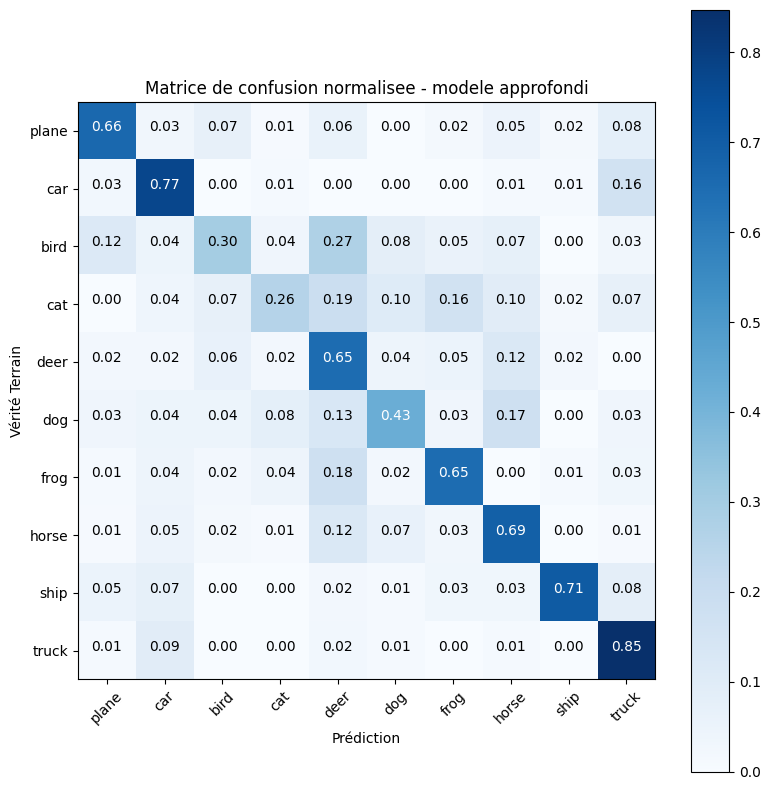

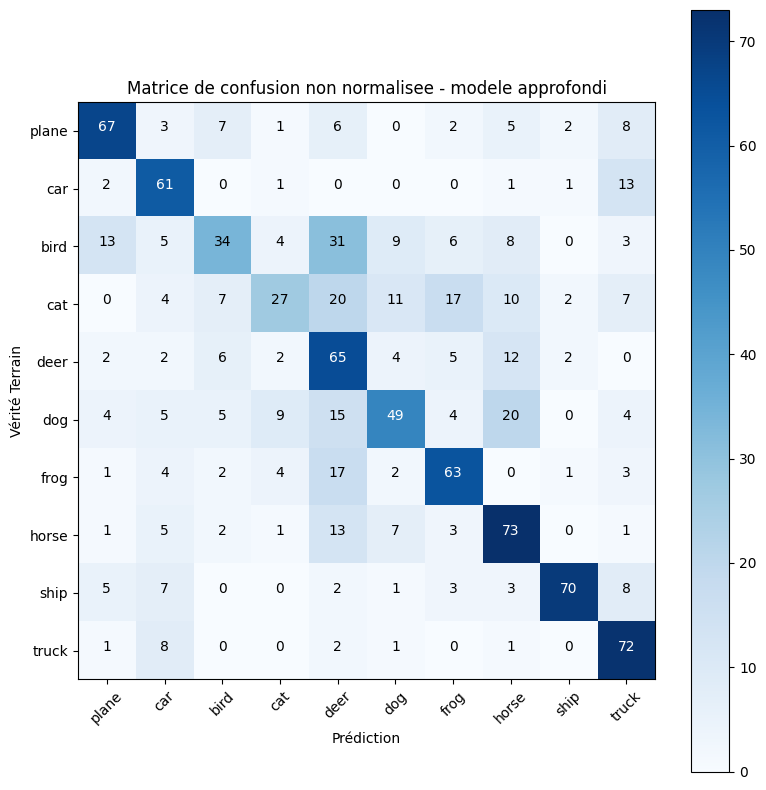

In [114]:
def confusion_matrix_from_model(model, x_data, y_data, class_names):
    pred = np.argmax(model.predict(x_data), axis=1)
    true = np.argmax(y_data, axis=1)
    n_classes = len(class_names)
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(true, pred):
        cm[t, p] += 1
    return cm

improved_confusion_matrix = confusion_matrix_from_model(improved_model, x_test, y_test, classes)

plot_confusion_matrix(improved_confusion_matrix, classes, normalize=True,
                      title='Matrice de confusion normalisee - modele approfondi')
plot_confusion_matrix(improved_confusion_matrix, classes,
                      title='Matrice de confusion non normalisee - modele approfondi')


### V.6. Exemples de predictions : modele de base vs modele approfondi

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


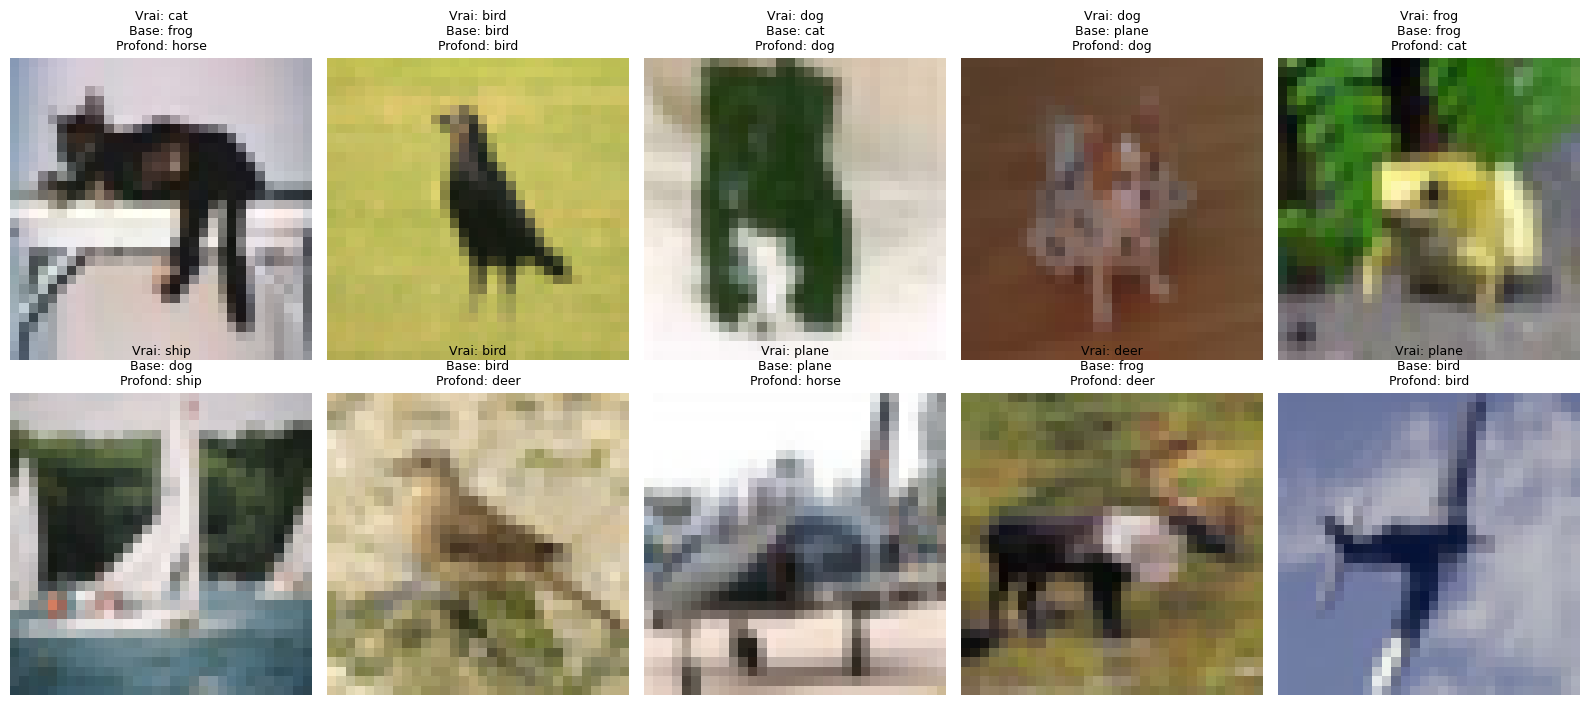

In [115]:
comparison_ids = np.random.choice(len(x_test), 10, replace=False)
base_pred = np.argmax(model.predict(x_test[comparison_ids]), axis=1)
improved_pred = np.argmax(improved_model.predict(x_test[comparison_ids]), axis=1)
true_pred = np.argmax(y_test[comparison_ids], axis=1)

fig, axarr = plt.subplots(2, 5, figsize=(16, 7))
for k, idx in enumerate(comparison_ids):
    ax = axarr[k // 5, k % 5]
    ax.imshow(x_test_initial[idx])
    ax.axis('off')
    ax.set_title(
        f"Vrai: {classes[true_pred[k]]}\nBase: {classes[base_pred[k]]}\nProfond: {classes[improved_pred[k]]}",
        fontsize=9
    )
plt.tight_layout()
plt.show()

### V.7. Critique du modele approfondi

**Avantages :**
- Le reseau multi-couches extrait des caracteristiques plus riches que le modele de base.
- La combinaison `Conv2D + BatchNormalization + MaxPooling + Dropout` rend l'apprentissage plus stable.
- L'optimiseur `Adam` accelere generalement la convergence.
- Les matrices de confusion permettent de mieux identifier les classes encore confondues.

**Limitations :**
- Le nombre de parametres est nettement plus eleve, donc le cout de calcul augmente.
- Avec seulement 5000 images d'apprentissage, le risque de surapprentissage reste important.
- Certaines classes visuellement proches dans CIFAR10 peuvent encore etre mal distinguees.
- Sans augmentation de donnees, les performances restent limitees par la taille reduite du jeu d'apprentissage.

**Conclusion :**
- Le modele approfondi est plus expressif et obtient en general de meilleures performances que le modele de base.
- En contrepartie, il demande plus de calcul et doit etre regularise avec soin.
- Une piste d'amelioration supplementaire serait d'ajouter de l'augmentation de donnees (`data augmentation`) ou un scheduler plus avance.